In [ ]:
%matplotlib notebook

"""
Prior to running this, create a new bundle in extension.py:

from zipline_norgatedata import register_norgatedata_futures_bundle

# This bundle is used in Trading Evolved: Chapter 18

register_norgatedata_futures_bundle(
    bundlename = 'norgatedata-tradingevolved-curvetrading',
    symbol_list = ['$SPXTR',],
    session_symbols = [
        'CL', # Crude Oil
        'HO', # NY Harbor ULSD
        'RB', # RBOB Gasoline - Jan 2006 onwards
        'HU', # Unleaded Gasoline - 1985 to Jan 2007 - available on request from Norgate
        'NG', # Henry Hub Natural Gas
        'GC', # Gold
        'ZC', # Corn
        'LE', # Live Cattle
        'ZS', # Soybeans
        'ZW', # Wheat
        'SB', # Sugar
        'HG', # Copper
        'CT', # Cotton
        'KC', # Coffee
        ],
    start_session = '2000-01-03',
)

and also run:

zipline ingest -b norgatedata-tradingevolved-curvetrading

"""

import zipline
from zipline.api import future_symbol,  \
    set_commission, set_slippage, schedule_function, \
    date_rules, time_rules, continuous_future, order_target, symbol, \
    set_benchmark

from pandas import Timestamp
import matplotlib.pyplot as plt
import pyfolio as pf
import pandas as pd
import numpy as np

from zipline.finance.commission import PerTrade, PerContract
from zipline.finance.slippage import FixedSlippage, VolatilityVolumeShare
import norgatedata

# We'll use this to find a future date, X months out.
from dateutil.relativedelta import relativedelta

# settings
spread_months = 12
pos_per_side = 5
target_exposure_per_side = 1.5
initial_portfolio_millions = 1
volume_order_cap = 0.25
print_daily_position_reports_and_trades = False

# DataFame for storing and updating the data that we want to graph
dynamic_results = pd.DataFrame()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(211)
ax.set_title('Curve Trading')
ax2 = fig.add_subplot(212)
ax2.set_title('Drawdown')

def initialize(context):
    #set_benchmark(symbol('$SPXTR'))    
   
    """
    Friction Settings
    """
    context.enable_commission = True
    context.enable_slippage = True  
   
    if context.enable_commission:
        comm_model = PerContract(cost=0.85, exchange_fee=1.5)
    else:
        comm_model = PerTrade(cost=0.0)
    set_commission(us_futures=comm_model)
   
    if context.enable_slippage:
        slippage_model=VolatilityVolumeShare(volume_limit=0.3)
    else:
        slippage_model=FixedSlippage(spread=0.0)      
    set_slippage(us_futures=slippage_model)
   
    """
    Markets to trade
    """
   
    af =  context.asset_finder
    most_liquid_commods = set([]) # a set eliminates dupes
    allcontracts = af.retrieve_futures_contracts(af.futures_sids)
    for contract in allcontracts:
        if allcontracts[contract].root_symbol != '':
            most_liquid_commods.add(allcontracts[contract].root_symbol)
    most_liquid_commods = list(most_liquid_commods)
    most_liquid_commods.sort()
   
    context.universe = [
        continuous_future(market, offset=0, roll='volume', adjustment='mul')
        for market in most_liquid_commods              
        ]
   
    schedule_function(weekly_trade, date_rules.week_start(), time_rules.market_close())
   
    schedule_function(update_chart,date_rules.month_start(), time_rules.market_close())      
   
def update_chart(context,data):
    # This function continuously update the graph during the backtest
    today = data.current_session.date()
    pv = context.portfolio.portfolio_value
    exp = context.portfolio.positions_exposure
    dynamic_results.loc[today, 'PortfolioValue'] = pv
   
    drawdown = (pv / dynamic_results['PortfolioValue'].max()) - 1
    exposure = exp / pv
    dynamic_results.loc[today, 'Drawdown'] = drawdown
   
    if ax.lines:
        ax.lines[0].set_xdata(dynamic_results.index)
        ax.lines[0].set_ydata(dynamic_results.PortfolioValue)
        ax2.lines[0].set_xdata(dynamic_results.index)
        ax2.lines[0].set_ydata(dynamic_results.Drawdown)
    else:
        ax.plot(dynamic_results.PortfolioValue)
        ax2.plot(dynamic_results.Drawdown)
       
    ax.set_ylim(
        dynamic_results.PortfolioValue.min(),
        dynamic_results.PortfolioValue.max()
    )
    ax.set_xlim(
        dynamic_results.index.min(),
        dynamic_results.index.max()
    )
    ax2.set_ylim(
        dynamic_results.Drawdown.min(),
        dynamic_results.Drawdown.max()
    )
    ax2.set_xlim(
        dynamic_results.index.min(),
        dynamic_results.index.max()
    )
   
    fig.canvas.draw()


def weekly_trade(context, data):
    if print_daily_position_reports_and_trades:
        print ('----------------------------------')
        print ('Date: ' + str(context.datetime))
        for contractheld in context.portfolio.positions:
            pos = context.portfolio.positions[contractheld]
            print ('Currently holding: ' + contractheld.symbol + ' ' + str(pos.amount) + ' contracts. Cost basis: ' + str(pos.cost_basis)  + ' Last trade: ' + str(pos.last_sale_price))
   
   
    # Empty DataFrame to be filled in later.
    carry_df = pd.DataFrame(index = context.universe)
   
    for continuation in context.universe:
       
        # Check if continuation has begun trading - if not, must be a new market
        if context.datetime.tz_localize(None) < continuation.start_date:
            continue
           
        # Get the chain
        chain = data.current_chain(continuation)

        # Transform the chain into dataframe
        df = pd.DataFrame({'future': pd.Series([], dtype='object'),
                           'expiration_date' : pd.Series([] , dtype='datetime64[ns]')},index = chain)
#                           'expiration_date' : pd.Series([] , dtype='datetime64[ns, UTC]')},index = chain)

        for contract in chain:
            df.loc[contract, 'future'] = contract
            df.loc[contract, 'expiration_date'] = contract.expiration_date
           
       
        # Locate the contract closest to the target date.
        # X months out from the front contract.
        closest_expiration_date = df.iloc[0].expiration_date
        target_expiration_date = closest_expiration_date + relativedelta(months=+spread_months)
        df['days_to_target'] = abs(df.expiration_date - target_expiration_date)
        target_contract = df.loc[df.days_to_target == df.days_to_target.min()]
       
        # Get prices for front contract and target contract
        prices = data.current(
            [
                df.index[0],
                target_contract.index[0]
            ],
            'close'
        )
       
        # Check the exact day difference between the contracts
        days_to_front = int(
            (target_contract.expiration_date - closest_expiration_date).iloc[0].days
        )
       
        # Calculate the annualized carry
        try:
            annualized_carry = (np.power(
                            (prices.iloc[0] / prices.iloc[1]), (365 / days_to_front))
                            ) - 1            
        except ZeroDivisionError:
            annualized_carry = 0        

        carry_df.loc[continuation, 'front'] = df.iloc[0].future
        carry_df.loc[continuation, 'next'] = target_contract.index[0]
        carry_df.loc[continuation, 'carry'] = annualized_carry
       
    # Sort on carry
    carry_df.sort_values('carry', inplace=True, ascending=False)
    carry_df.dropna(inplace=True)
   
    new_portfolio = []
    new_longs = []
    new_shorts = []

    # Contract Selection
    for i in np.arange(0, pos_per_side):
        j = -(i+1)
       
        # Buy top, short bottom
        long_contract = carry_df.iloc[i].next
        short_contract = carry_df.iloc[j].next
       
        new_longs.append(long_contract)
        new_shorts.append(short_contract)

    # Get data for the new portfolio
    new_portfolio = new_longs + new_shorts
    hist = data.history(new_portfolio,  fields=['close','volume'],
        frequency='1d',
        bar_count=10,
        )
   
    # Simple Equal Weighted
    target_weight = (
        target_exposure_per_side  * context.portfolio.portfolio_value
        ) / pos_per_side
   
    # Trading
    for contract in new_portfolio:
        # Slice history for contract
        h = hist.xs(contract, level=1)

       
        # Equal weighted, with volume based cap.
        contracts_to_trade = target_weight / \
            contract.price_multiplier / \
            h.close[-1]
       
        # Position size cap
        contracts_cap = int(h['volume'].mean() * volume_order_cap)
       
        # Limit trade size to position size cap.
        contracts_to_trade = min(contracts_to_trade, contracts_cap)
       
        # Negative position for shorts
        if contract in new_shorts:
            contracts_to_trade *= -1
           
       
        # Execute
        order_target(contract, contracts_to_trade)
        if print_daily_position_reports_and_trades:
            prevamountheld = 0
            if context.portfolio.positions[contract]:
                prevamountheld = context.portfolio.positions[contract].amount
            print ('Changing position on ' + contract.symbol + " from " + str(prevamountheld) + " to " + str(contracts_to_trade))

    # Close any other open position
    for pos in context.portfolio.positions:
        if pos not in new_portfolio:
            if print_daily_position_reports_and_trades:
                print ('Exiting position contract: ' + pos.symbol + ' ' + str(context.portfolio.positions[pos].amount) + ' contracts')
            #                pos = context.portfolio.positions[contractheld]
            #print ('Currently holding: ' + contractheld.symbol + ' ' + str(pos.amount) + ' contracts. Cost basis: ' + str(pos.cost_basis)  + ' Last trade: ' + str(pos.last_sale_price))
            order_target(pos, 0.0)

start_date = Timestamp('2007-01-01')
end_date = Timestamp('2024-08-29')

# Turn off all warnings to make the output a little nicer:
import warnings
warnings.filterwarnings("ignore")

perf = zipline.run_algorithm(
    start=start_date, end=end_date,
    initialize=initialize,
    capital_base=initial_portfolio_millions * 1000000,  
    data_frequency = 'daily',
    bundle='norgatedata-tradingevolved-curvetrading'
)

<IPython.core.display.Javascript object>

Cannot place order for HUF07, as it has de-listed. Any existing positions for this asset will be liquidated on 2006-12-27 00:00:00.
Cannot place order for HUF07, as it has de-listed. Any existing positions for this asset will be liquidated on 2006-12-27 00:00:00.
Cannot place order for HUF07, as it has de-listed. Any existing positions for this asset will be liquidated on 2006-12-27 00:00:00.
Cannot place order for HUF07, as it has de-listed. Any existing positions for this asset will be liquidated on 2006-12-27 00:00:00.
Cannot place order for HUF07, as it has de-listed. Any existing positions for this asset will be liquidated on 2006-12-27 00:00:00.
Cannot place order for HUF07, as it has de-listed. Any existing positions for this asset will be liquidated on 2006-12-27 00:00:00.
Cannot place order for HUF07, as it has de-listed. Any existing positions for this asset will be liquidated on 2006-12-27 00:00:00.
Cannot place order for HUF07, as it has de-listed. Any existing positions fo

Start date,2007-01-04
End date,2024-08-29
Total months,211
,Backtest
Annual return,13.945%
Cumulative returns,899.628%
Annual volatility,20.384%
Sharpe ratio,0.74
Calmar ratio,0.39
Stability,0.88
Max drawdown,-35.342%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,35.34,2019-05-10,2020-08-28,2022-04-18,767
1,26.38,2016-01-20,2017-01-17,2018-01-12,518
2,23.44,2022-06-09,2022-12-19,NaT,NaN
3,20.44,2009-02-18,2009-06-02,2009-09-01,140
4,18.93,2013-11-14,2014-05-06,2014-09-19,222


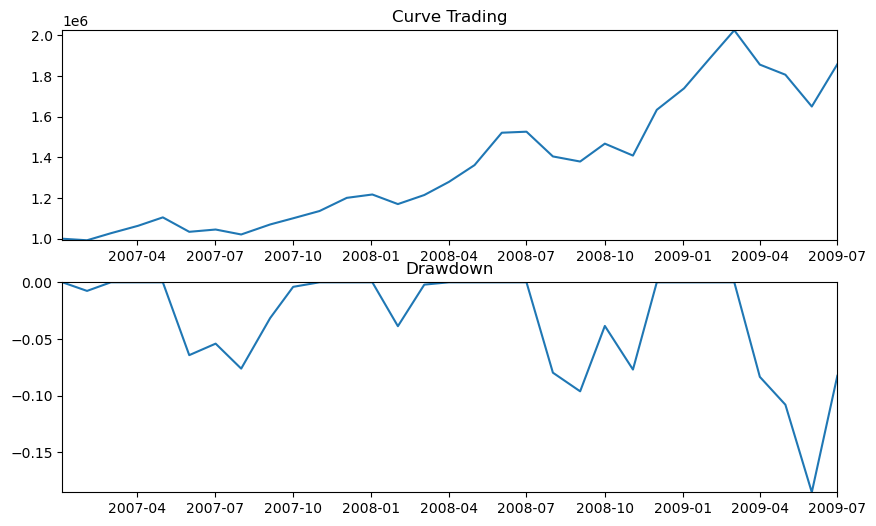

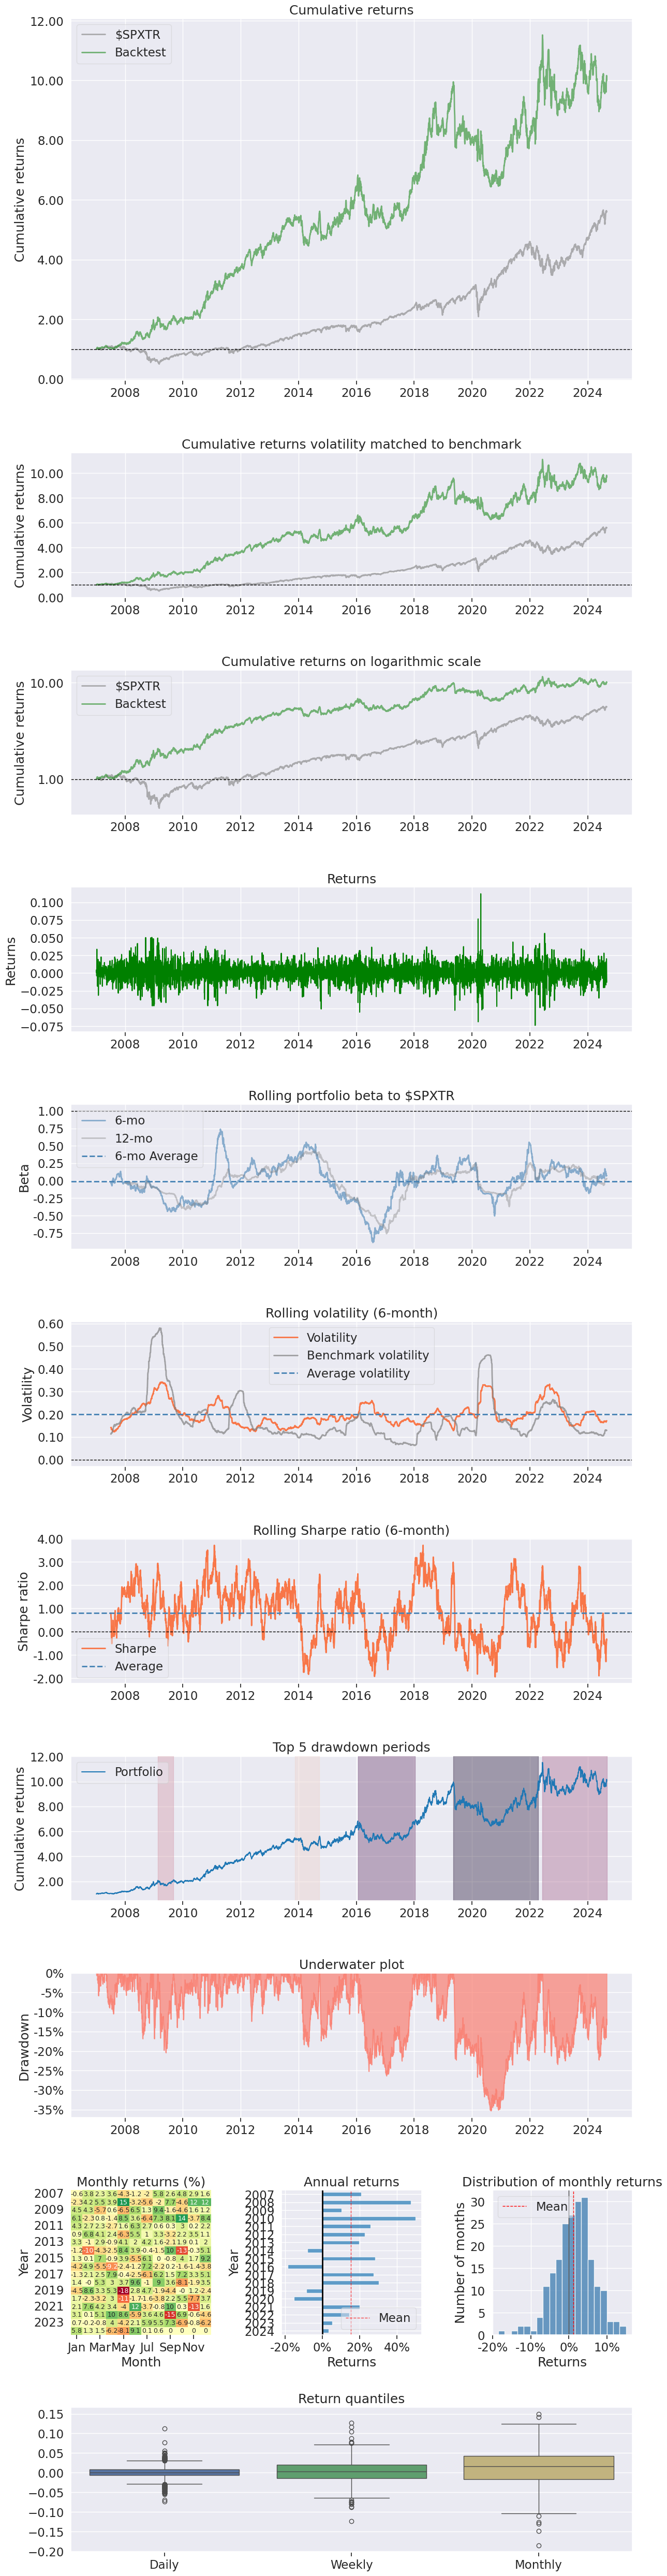

In [5]:
%matplotlib inline
returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf)
spxtr = norgatedata.price_timeseries(
    '$SPXTR',
    start_date = returns.index[0],
    end_date = returns.index[-1],
    format='pandas-dataframe',
    timezone='UTC',
)
spxtr_rets = spxtr['Close'].pct_change().dropna()
spxtr_rets.name = '$SPXTR'

# The following supresses all warnings - mainly because there is some code within pyfolio, 
# empyrical, pandas and matplotlib that has deprecated calls - this just supresses the
# warnings from showing
import warnings
warnings.filterwarnings('ignore')

pf.create_returns_tear_sheet(returns, benchmark_rets=spxtr_rets)

In [ ]:
perf.portfolio_value.to_csv('../Backtests/curve_trading.csv')